<a href="https://colab.research.google.com/github/taijarals/github_score_engajamento/blob/main/analise_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 GitHub Engagement Analysis

## 🎯 Objetivo
Analisar o engajamento dos contribuidores de um repositório do GitHub, considerando:

- Commits
- Pull Requests (abertos e aprovados)
- Issues
- Atividade ao longo do tempo

## 📊 Outputs esperados
- Ranking de contribuidores
- Métricas de engajamento
- Evolução temporal
- Insights sobre produtividade

Imports

In [8]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

Token GitHub

In [9]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

HEADERS = {"Authorization": f"token {GITHUB_TOKEN}"} if GITHUB_TOKEN else {}

print("Token carregado:", bool(GITHUB_TOKEN))

Token carregado: True


Funções de API

In [10]:
def fetch(url):
    response = requests.get(url, headers=HEADERS)

    if response.status_code != 200:
        print(f"Erro {response.status_code}: {response.text}")
        return []

    try:
        return response.json()
    except:
        return []

Paginação

In [11]:
def fetch_all(url):
    results = []
    page = 1

    while True:
        paginated_url = f"{url}&page={page}"
        data = fetch(paginated_url)

        if not data:
            break

        results.extend(data)
        page += 1

    return results

Função principal

In [12]:
def build_github_df(owner, repo):

    contributors = fetch(f"https://api.github.com/repos/{owner}/{repo}/contributors")
    pulls = fetch_all(f"https://api.github.com/repos/{owner}/{repo}/pulls?state=all&per_page=100")
    issues = fetch_all(f"https://api.github.com/repos/{owner}/{repo}/issues?state=all&per_page=100")

    data = {}
    timeline = []

    # -----------------------------
    # COMMITS
    # -----------------------------
    for c in contributors:
        if "login" not in c:
            continue

        data[c["login"]] = {
            "commits": c.get("contributions", 0),
            "prs_opened": 0,
            "prs_merged": 0,
            "issues": 0,
            "last_activity": None
        }

    # -----------------------------
    # PRs
    # -----------------------------
    for pr in pulls:
        if not pr.get("user"):
            continue

        user = pr["user"]["login"]

        data.setdefault(user, {
            "commits": 0,
            "prs_opened": 0,
            "prs_merged": 0,
            "issues": 0,
            "last_activity": None
        })

        data[user]["prs_opened"] += 1

        if pr.get("merged_at"):
            data[user]["prs_merged"] += 1

        if pr.get("created_at"):
            date = pr["created_at"][:10]
            timeline.append({"date": date, "user": user})
            data[user]["last_activity"] = date

    # -----------------------------
    # ISSUES
    # -----------------------------
    for issue in issues:
        if "pull_request" in issue:
            continue

        if not issue.get("user"):
            continue

        user = issue["user"]["login"]

        data.setdefault(user, {
            "commits": 0,
            "prs_opened": 0,
            "prs_merged": 0,
            "issues": 0,
            "last_activity": None
        })

        data[user]["issues"] += 1

        if issue.get("created_at"):
            date = issue["created_at"][:10]
            timeline.append({"date": date, "user": user})
            data[user]["last_activity"] = date

    df = pd.DataFrame.from_dict(data, orient="index")

    # -----------------------------
    # FEATURE ENGINEERING
    # -----------------------------
    df["score"] = (
        df["commits"] +
        df["prs_opened"] * 2 +
        df["prs_merged"] * 5 +
        df["issues"]
    )

    df["merge_rate"] = df["prs_merged"] / df["prs_opened"].replace(0, 1)
    df["total_activity"] = df[["commits", "prs_opened", "issues"]].sum(axis=1)

    timeline_df = pd.DataFrame(timeline)

    return df, timeline_df

  Execução

In [14]:
#owner = "microsoft"
#repo = "vscode"
#https://github.com/ariannesuelen-lang/Challenge_system

owner = "ariannesuelen-lang"
repo = "Challenge_system"

df, timeline = build_github_df(owner, repo)

df.head()

,commits,prs_opened,prs_merged,issues,last_activity,score,merge_rate,total_activity
SarahPaoliello,13,1,1,4,2026-04-06,24,1.0,18
Andrew42400,3,0,0,0,None,3,0.0,3
taijarals,3,0,0,0,None,3,0.0,3
Jacksonfvsantos,2,0,0,0,None,2,0.0,2
ariannesuelen-lang,2,0,0,1,2026-04-04,3,0.0,3


Top contribuidores

In [15]:
top10 = df.sort_values("score", ascending=False).head(10)
top10

,commits,prs_opened,prs_merged,issues,last_activity,score,merge_rate,total_activity
SarahPaoliello,13,1,1,4,2026-04-06,24,1.0,18
jgabriell-bispo,1,2,0,0,2026-03-30,5,0.0,3
Andrew42400,3,0,0,0,None,3,0.0,3
ariannesuelen-lang,2,0,0,1,2026-04-04,3,0.0,3
taijarals,3,0,0,0,None,3,0.0,3
Jacksonfvsantos,2,0,0,0,None,2,0.0,2
CaiqueHighTech,1,0,0,0,None,1,0.0,1
csacerdote,1,0,0,0,None,1,0.0,1
Favel1nhah,1,0,0,0,None,1,0.0,1
Ferfe11,1,0,0,0,None,1,0.0,1


Estatísticas gerais

In [16]:
df.describe()

,commits,prs_opened,prs_merged,issues,score,merge_rate,total_activity
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,1.739130,0.130435,0.043478,0.260870,2.478261,0.043478,2.130435
std,2.544466,0.457697,0.208514,0.864312,4.804066,0.208514,3.545860
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,1.500000,0.000000,1.500000
max,13.000000,2.000000,1.000000,4.000000,24.000000,1.000000,18.000000


Correlação

In [17]:
df.corr(numeric_only=True)

,commits,prs_opened,prs_merged,issues,score,merge_rate,total_activity
commits,1.000000,0.381819,0.964754,0.900430,0.973771,0.964754,0.986355
prs_opened,0.381819,1.000000,0.414158,0.369686,0.549167,0.414158,0.493180
prs_merged,0.964754,0.414158,1.000000,0.943064,0.976584,1.000000,0.975629
issues,0.900430,0.369686,0.943064,1.000000,0.931928,0.943064,0.937609
score,0.973771,0.549167,0.976584,0.931928,1.000000,0.976584,0.996812
merge_rate,0.964754,0.414158,1.000000,0.943064,0.976584,1.000000,0.975629
total_activity,0.986355,0.493180,0.975629,0.937609,0.996812,0.975629,1.000000


Distribuição de score

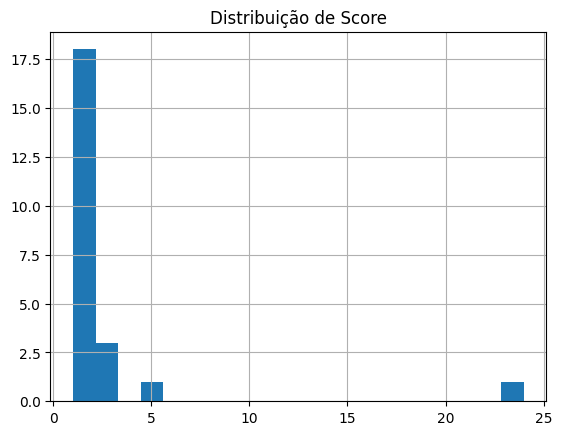

In [18]:
df["score"].hist(bins=20)
plt.title("Distribuição de Score")
plt.show()

Evolução temporal

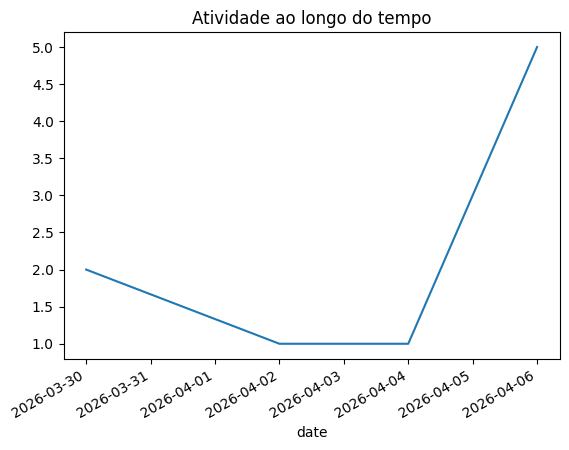

In [19]:
timeline["date"] = pd.to_datetime(timeline["date"])

timeline.groupby("date").size().plot()
plt.title("Atividade ao longo do tempo")
plt.show()

Insights rápidos

In [20]:
print("Usuário mais ativo:")
print(df["score"].idxmax())

print("\nUsuário com mais PRs aprovados:")
print(df["prs_merged"].idxmax())

print("\nUsuário com mais issues:")
print(df["issues"].idxmax())

Usuário mais ativo:
SarahPaoliello

Usuário com mais PRs aprovados:
SarahPaoliello

Usuário com mais issues:
SarahPaoliello


Exportar dados

In [21]:
df.to_csv("github_analysis.csv")
timeline.to_csv("timeline.csv")

In [22]:
from sklearn.cluster import KMeans

features = df[["commits", "prs_opened", "prs_merged", "issues"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(features)

df.head()

,commits,prs_opened,prs_merged,issues,last_activity,score,merge_rate,total_activity,cluster
SarahPaoliello,13,1,1,4,2026-04-06,24,1.0,18,1
Andrew42400,3,0,0,0,None,3,0.0,3,2
taijarals,3,0,0,0,None,3,0.0,3,2
Jacksonfvsantos,2,0,0,0,None,2,0.0,2,2
ariannesuelen-lang,2,0,0,1,2026-04-04,3,0.0,3,2
